# Pipeline #3: Reintegration Readiness (Forward Classifier)

## 1. Problem Framing

### Business Question
Which residents should staff review first for reintegration planning, so no one is missed when teams are busy?

This model helps staff **prioritize reviews**. It does **not** make automatic reintegration decisions.

### What the model predicts

| Label | Plain-language meaning |
|:---|:---|
| **`y_ready_within_3m`** *(main label)* | 1 = likely to complete reintegration in about the next 3 months. |
| **`y_next_ready`** *(extra reference label)* | 1 = likely to complete reintegration next month only. |

**Who gets scored:** residents who are **not already completed** in the current month.

### Predictive and Explanatory Modeling Map

| Part | Sections | Why it matters |
|:---|:---|:---|
| **Prediction results** | **3** and **4** | Shows model quality, threshold choices, and who appears in the priority list. |
| **Pattern explanation** | **3** and **5** | Shows which factors are linked with readiness (helpful context, not proof of cause). |

### Predictive vs explanatory (per course framework)

This pipeline uses **both goals deliberately**, consistent with the textbook split: **predictive** work (Sections 3–4) optimizes ranking and held-out performance so staff can decide *who to review first* under limited time. **Explanatory** work (Sections 3 and 5) keeps a transparent, interpretable model to discuss *which resident-month patterns line up with readiness* in the historical data. We do **not** treat predictive accuracy as proof of causation; we use explanatory coefficients as structured hypotheses for supervision and case conference, not as automatic discharge rules.


## 2. Data Acquisition, Preparation & Exploration

### How the data is set up
- Each row is one resident in one month.
- We use that month’s information to predict whether completion is likely in the next ~3 months.

### Rules to keep the model fair
1. We do not give the model direct “answer” fields.
2. We only use information available at that time (not future data).
3. We keep train/validation/test in calendar order.
4. We only score residents who are not already completed.

### Feature glossary (engineered fields)
| Field pattern / term | Plain-language definition |
|:---|:---|
| **Timing assumption (all engineered features)** | Features are calculated using information available at month **m** (or earlier), then used to predict future readiness. |
| **`*_3m_mean`** | Average value over the **last 3 months**, ending at month **m**. |
| **`*_3m_sum`** | Total over the **last 3 months**, ending at month **m**. |
| **`*_cum_mean`** | Average from the resident's first observed month up to month **m**. |
| **`*_cum_sum`** | Running total from first observed month up to month **m**. |
| **`attendance_rate_3m_mean`** | Average attendance rate during the last 3 months (through month **m**). |
| **`progress_rate_3m_mean`** | Average share of sessions marked as progress during the last 3 months. |
| **`incident_count_3m_sum`** | Total incidents in the last 3 months. |
| **`incident_severity_mean_3m_mean`** | Average incident severity across the last 3 months. |
| **`months_since_admission`** | How long the resident has been in the program at month **m**. |

### Important labels
| Label | Plain-language meaning |
|:---|:---|
| **`y_ready_within_3m`** | Main target. 1 means likely to complete in about the next 3 months. |
| **`y_next_ready`** | Extra strict version. 1 means likely to complete next month only. |

### Simple reading guide for outputs
| Output | How to read it |
|:---|:---|
| **`y_3m_rate`** | How common “ready within 3 months” is in that split. |
| **`val_pr_auc`** | Main score used to pick the model (better for rare outcomes). |
| **Precision** | Of people flagged, how many were truly positive. |
| **Recall** | Of true positives, how many we successfully flagged. |
| **Top-K** | If staff can only review K cases, how well does the top K list perform? |
| **`recall_at_k`** | Of all true positives that month, how many appear in top K. |
| **`coef`** | Direction/strength of association in the explanatory model. |
| **`odds_ratio`** | How odds change when a feature rises by one unit (above 1 = higher odds, below 1 = lower odds). |
| **`p_value`** | Statistical evidence strength for that feature's association (smaller usually means stronger evidence). |

### Important caution
A positive model score means **“review this case soon”** — not “automatically reintegrate now.”


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib

# Force notebook-only rendering before importing pyplot.
try:
    matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
except Exception:
    pass

import matplotlib.pyplot as plt
plt.ioff()

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None
    plt.style.use('seaborn-v0_8-whitegrid')

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

try:
    import statsmodels.api as sm
except Exception:
    sm = None

# Keep plots rendered in the notebook instead of external windows.
try:
    ip = get_ipython()  # type: ignore[name-defined]
    if ip is not None:
        ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

RANDOM_STATE = 42
TIMELINE_CUTOFF = pd.Timestamp('2026-03-01')


def resolve_data_dir() -> Path:
    candidates = [Path('data'), Path('../data'), Path('../../data'), Path.cwd() / 'data']
    for c in candidates:
        if c.exists() and (c / 'residents.csv').exists():
            return c
    raise FileNotFoundError('Could not locate data directory containing residents.csv')


def month_key(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors='coerce').dt.to_period('M').dt.to_timestamp()


def yes_no_to_bin(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)
    if pd.api.types.is_numeric_dtype(series):
        return (series.fillna(0) > 0).astype(int)
    mapped = series.astype(str).str.strip().str.lower().map({'yes': 1, 'true': 1, '1': 1, 'no': 0, 'false': 0, '0': 0})
    return mapped.fillna(0).astype(int)


def add_rollups(monthly_df: pd.DataFrame, id_col='resident_id', month_col='month') -> pd.DataFrame:
    monthly_df = monthly_df.sort_values([id_col, month_col]).copy()
    num_cols = [c for c in monthly_df.columns if c not in [id_col, month_col]]
    out = monthly_df[[id_col, month_col]].copy()
    for c in num_cols:
        grp = monthly_df.groupby(id_col)[c]
        out[f'{c}_3m_mean'] = grp.transform(lambda s: s.rolling(3, min_periods=1).mean())
        out[f'{c}_3m_sum'] = grp.transform(lambda s: s.rolling(3, min_periods=1).sum())
        out[f'{c}_cum_mean'] = grp.transform(lambda s: s.expanding().mean().reset_index(level=0, drop=True))
        out[f'{c}_cum_sum'] = grp.transform(lambda s: s.expanding().sum().reset_index(level=0, drop=True))
    return out


DATA_DIR = resolve_data_dir()
print(f'Using data directory: {DATA_DIR.resolve()}')

residents = pd.read_csv(DATA_DIR / 'residents.csv')
process = pd.read_csv(DATA_DIR / 'process_recordings.csv')
home = pd.read_csv(DATA_DIR / 'home_visitations.csv')
edu = pd.read_csv(DATA_DIR / 'education_records.csv')
health = pd.read_csv(DATA_DIR / 'health_wellbeing_records.csv')
interventions = pd.read_csv(DATA_DIR / 'intervention_plans.csv')
incidents = pd.read_csv(DATA_DIR / 'incident_reports.csv')

for df, col in [
    (process, 'session_date'),
    (home, 'visit_date'),
    (edu, 'record_date'),
    (health, 'record_date'),
    (interventions, 'created_at'),
    (incidents, 'incident_date'),
    (residents, 'date_of_admission'),
]:
    df[col] = pd.to_datetime(df[col], errors='coerce')

residents['is_completed_now'] = (residents['reintegration_status'].fillna('').str.lower() == 'completed').astype(int)

activity_frames = []
for df, date_col in [
    (process[['resident_id', 'session_date']].copy(), 'session_date'),
    (home[['resident_id', 'visit_date']].copy(), 'visit_date'),
    (edu[['resident_id', 'record_date']].copy(), 'record_date'),
    (health[['resident_id', 'record_date']].copy(), 'record_date'),
    (interventions[['resident_id', 'created_at']].copy(), 'created_at'),
    (incidents[['resident_id', 'incident_date']].copy(), 'incident_date'),
]:
    df['month'] = month_key(df[date_col])
    activity_frames.append(df[['resident_id', 'month']])

base = pd.concat(activity_frames, ignore_index=True).dropna().drop_duplicates()
base = base.merge(
    residents[['resident_id', 'is_completed_now', 'date_of_admission', 'safehouse_id', 'case_category', 'initial_risk_level', 'current_risk_level']],
    on='resident_id',
    how='left'
)
base['months_since_admission'] = (
    (base['month'].dt.year - base['date_of_admission'].dt.year) * 12 +
    (base['month'].dt.month - base['date_of_admission'].dt.month)
).clip(lower=0)

proc = process.copy()
proc['month'] = month_key(proc['session_date'])
proc['concerns_flagged_bin'] = yes_no_to_bin(proc['concerns_flagged'])
proc['referral_made_bin'] = yes_no_to_bin(proc['referral_made'])
proc['progress_noted_bin'] = yes_no_to_bin(proc['progress_noted'])
emotion_risk = {'Calm': 0, 'Neutral': 1, 'Anxious': 2, 'Distressed': 3, 'Withdrawn': 2, 'Angry': 2}
proc['emotion_observed_score'] = proc['emotional_state_observed'].map(emotion_risk).fillna(1)
proc['emotion_end_score'] = proc['emotional_state_end'].map(emotion_risk).fillna(1)
proc_m = proc.groupby(['resident_id', 'month'], as_index=False).agg(
    sessions=('recording_id', 'count'),
    session_minutes=('session_duration_minutes', 'sum'),
    concern_rate=('concerns_flagged_bin', 'mean'),
    referral_rate=('referral_made_bin', 'mean'),
    progress_rate=('progress_noted_bin', 'mean'),
    emotion_observed_mean=('emotion_observed_score', 'mean'),
    emotion_end_mean=('emotion_end_score', 'mean'),
)
proc_roll = add_rollups(proc_m)

home2 = home.copy()
home2['month'] = month_key(home2['visit_date'])
home2['safety_concern_bin'] = yes_no_to_bin(home2['safety_concerns_noted'])
home2['follow_up_bin'] = yes_no_to_bin(home2['follow_up_needed'])
coop_map = {'High': 2, 'Medium': 1, 'Low': 0}
home2['cooperation_score'] = home2['family_cooperation_level'].map(coop_map).fillna(1)
home_m = home2.groupby(['resident_id', 'month'], as_index=False).agg(
    visits=('visitation_id', 'count'),
    safety_concern_rate=('safety_concern_bin', 'mean'),
    followup_rate=('follow_up_bin', 'mean'),
    cooperation_mean=('cooperation_score', 'mean'),
)
home_roll = add_rollups(home_m)

edu2 = edu.copy()
edu2['month'] = month_key(edu2['record_date'])
edu_m = edu2.groupby(['resident_id', 'month'], as_index=False).agg(
    attendance_rate=('attendance_rate', 'mean'),
    progress_percent=('progress_percent', 'mean'),
)
edu_roll = add_rollups(edu_m)

health2 = health.copy()
health2['month'] = month_key(health2['record_date'])
health_m = health2.groupby(['resident_id', 'month'], as_index=False).agg(
    general_health_score=('general_health_score', 'mean'),
    nutrition_score=('nutrition_score', 'mean'),
    sleep_quality_score=('sleep_quality_score', 'mean'),
    energy_level_score=('energy_level_score', 'mean'),
)
health_roll = add_rollups(health_m)

ip = interventions.copy()
ip['month'] = month_key(ip['created_at'])
ip['is_open'] = ip['status'].fillna('').str.lower().isin(['open', 'in progress']).astype(int)
ip['is_achieved'] = ip['status'].fillna('').str.lower().eq('achieved').astype(int)
ip_m = ip.groupby(['resident_id', 'month'], as_index=False).agg(
    intervention_count=('plan_id', 'count'),
    open_share=('is_open', 'mean'),
    achieved_share=('is_achieved', 'mean'),
)
ip_roll = add_rollups(ip_m)

inc = incidents.copy()
inc['month'] = month_key(inc['incident_date'])
sev_map = {'Low': 1, 'Medium': 2, 'High': 3}
inc['severity_score'] = inc['severity'].map(sev_map).fillna(1)
inc['followup_required_bin'] = yes_no_to_bin(inc['follow_up_required'])
inc_m = inc.groupby(['resident_id', 'month'], as_index=False).agg(
    incident_count=('incident_id', 'count'),
    incident_severity_mean=('severity_score', 'mean'),
    incident_followup_rate=('followup_required_bin', 'mean'),
)
inc_roll = add_rollups(inc_m)

feature_df = base.copy()
for block in [proc_roll, home_roll, edu_roll, health_roll, ip_roll, inc_roll]:
    feature_df = feature_df.merge(block, on=['resident_id', 'month'], how='left')

# Restrict to observed operational period only.
feature_df = feature_df[feature_df['month'] <= TIMELINE_CUTOFF].copy()

for c in feature_df.columns:
    if c.endswith('_sum') or 'count' in c or 'sessions' in c or 'visits' in c:
        feature_df[c] = feature_df[c].fillna(0)

feature_df = feature_df.sort_values(['resident_id', 'month']).copy()
completion_month_map = (
    feature_df.loc[feature_df['is_completed_now'] == 1]
    .groupby('resident_id')['month']
    .max()
)
feature_df['completion_month_proxy'] = feature_df['resident_id'].map(completion_month_map)
feature_df['next_month'] = (feature_df['month'] + pd.offsets.MonthBegin(1)).dt.normalize()
feature_df['y_next_ready'] = (
    feature_df['completion_month_proxy'].notna() &
    (feature_df['next_month'] == feature_df['completion_month_proxy'])
).astype(int)
_p_comp = feature_df['completion_month_proxy'].dt.to_period('M')
_p_start = feature_df['next_month'].dt.to_period('M')
feature_df['y_ready_within_3m'] = (
    feature_df['completion_month_proxy'].notna()
    & (_p_comp >= _p_start)
    & (_p_comp <= _p_start + 2)
).astype(int)
feature_df = feature_df[
    feature_df['completion_month_proxy'].isna() |
    (feature_df['month'] < feature_df['completion_month_proxy'])
].copy()

label_next = feature_df['y_next_ready'].value_counts(dropna=False).rename_axis('y_next_ready').reset_index(name='count')
label_next['share'] = label_next['count'] / label_next['count'].sum()
display(label_next)
label_3m = feature_df['y_ready_within_3m'].value_counts(dropna=False).rename_axis('y_ready_within_3m').reset_index(name='count')
label_3m['share'] = label_3m['count'] / label_3m['count'].sum()
display(label_3m)
print('Primary target for modeling: y_ready_within_3m (1 = completion proxy falls in month m+1, m+2, or m+3). First table = strict next-month-only label.')

candidate_cols = [c for c in feature_df.columns if c not in ['resident_id', 'month', 'y_next_ready', 'y_ready_within_3m', 'date_of_admission']]
non_cat = [c for c in candidate_cols if c not in ['safehouse_id', 'case_category', 'initial_risk_level', 'current_risk_level']]
feature_df = feature_df.dropna(subset=non_cat, how='all')

print(f'Final modeling rows: {len(feature_df):,}, columns: {feature_df.shape[1]}')

display(feature_df.groupby('month').size().reset_index(name='rows').tail(12))

Using data directory: G:\My Drive\Winter 2026\IS 455 - Machine Learning (MK)\INTEX\data


,y_next_ready,count,share
0,0,1088,0.982836
1,1,19,0.017164


,y_ready_within_3m,count,share
0,0,1051,0.949413
1,1,56,0.050587


Primary target for modeling: y_ready_within_3m (1 = completion proxy falls in month m+1, m+2, or m+3). First table = strict next-month-only label.
Final modeling rows: 1,107, columns: 105


,month,rows
27,2025-04-01,41
28,2025-05-01,40
29,2025-06-01,40
30,2025-07-01,38
31,2025-08-01,37
32,2025-09-01,35
33,2025-10-01,38
34,2025-11-01,36
35,2025-12-01,33
36,2026-01-01,34


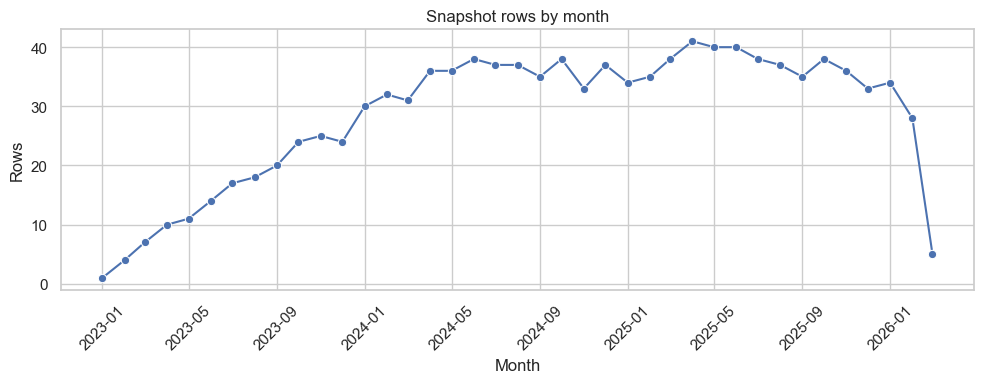

What this means: we have a usable month-by-month panel for time-aware validation and operations.


In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
month_counts = feature_df.groupby('month').size().reset_index(name='rows')
if sns is not None:
    sns.lineplot(data=month_counts, x='month', y='rows', marker='o', ax=ax)
else:
    ax.plot(month_counts['month'], month_counts['rows'], marker='o')
ax.set_title('Snapshot rows by month')
ax.set_xlabel('Month')
ax.set_ylabel('Rows')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('What this means: we have a usable month-by-month panel for time-aware validation and operations.')

## 3. Modeling & Feature Selection

### What this step does
- Trains two models on past months.
- Picks the better one using validation performance.
- Creates a small explanation table to help staff discuss patterns.

### Feature selection and leakage controls
- **Included:** rolling and cumulative history through month *m* (sessions, attendance/progress, health/sleep, incidents, tenure) that plausibly relate to readiness and are available at scoring time.
- **Excluded:** direct outcome fields (`reintegration_status`, `reintegration_type`, `completion_month_proxy`, labels, ids, raw dates), long narrative text, and anything that would encode the answer the model is asked to predict. `resident_id` and `month` stay out of *X* but are kept in the panel for joins and reporting.
- **Explanatory subset:** the logistic table uses a **short, readable** feature list (not every column) so coefficients stay discussable in case conferences. Predictive models use the full numeric + categorical *X* after exclusions.

### Algorithms and hyperparameters
We **compare** balanced logistic regression and a class-weighted random forest on validation PR-AUC instead of a large grid search, so the time-ordered split stays simple to audit. Forest settings (`n_estimators`, `min_samples_leaf`) are moderate defaults aimed at stability on a tabular panel; the main tuning lever for operations remains the **decision threshold** and Top-K policy in Section 4.

### How to read this section
If a term is unfamiliar, check Section 2 for plain-language definitions.


In [3]:
months = sorted(feature_df['month'].dropna().unique())
if len(months) < 5:
    raise ValueError('Not enough distinct months for robust time split.')

n = len(months)
train_end = max(1, int(n * 0.6))
val_end = max(train_end + 1, int(n * 0.8))
train_months = months[:train_end]
val_months = months[train_end:val_end]
test_months = months[val_end:]

PRIMARY_TARGET = 'y_ready_within_3m'

feature_df['split'] = np.where(feature_df['month'].isin(train_months), 'train', np.where(feature_df['month'].isin(val_months), 'val', 'test'))
split_summary = feature_df.groupby('split').agg(
    rows=('resident_id', 'size'),
    y_3m_rate=(PRIMARY_TARGET, 'mean'),
    y_next_mo_rate=('y_next_ready', 'mean'),
)
display(split_summary)
print('rows = resident-month count; y_3m_rate = primary target (complete within next 3 months); y_next_mo_rate = strict next-month only.')

leakage_exclusions = {'y_next_ready', 'y_ready_within_3m', 'is_completed_now', 'completion_month_proxy', 'next_month', 'reintegration_status', 'reintegration_type', 'resident_id', 'month', 'date_of_admission', 'split'}
X_cols = [c for c in feature_df.columns if c not in leakage_exclusions]
X = feature_df[X_cols].copy()
y = feature_df[PRIMARY_TARGET].astype(int)

X_train, y_train = X[feature_df['split'] == 'train'], y[feature_df['split'] == 'train']
X_val, y_val = X[feature_df['split'] == 'val'], y[feature_df['split'] == 'val']
X_test, y_test = X[feature_df['split'] == 'test'], y[feature_df['split'] == 'test']

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features),
])

models = {
    'logistic_balanced': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'random_forest_balanced': RandomForestClassifier(n_estimators=350, min_samples_leaf=2, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
}

results, trained = [], {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    val_scores = pipe.predict_proba(X_val)[:, 1]
    results.append({
        'model': name,
        'val_pr_auc': average_precision_score(y_val, val_scores) if y_val.nunique() > 1 else np.nan,
        'val_roc_auc': roc_auc_score(y_val, val_scores) if y_val.nunique() > 1 else np.nan,
    })
    trained[name] = pipe

model_compare = pd.DataFrame(results).sort_values('val_pr_auc', ascending=False)
display(model_compare)

best_model_name = model_compare.iloc[0]['model']
best_model = trained[best_model_name]
print(f'Selected predictive model: {best_model_name}')

explain_cols = [
    'months_since_admission', 'sessions_3m_sum', 'concern_rate_3m_mean', 'progress_rate_3m_mean',
    'attendance_rate_3m_mean', 'progress_percent_3m_mean', 'general_health_score_3m_mean',
    'sleep_quality_score_3m_mean', 'incident_count_3m_sum', 'incident_severity_mean_3m_mean',
]
explain_cols = [c for c in explain_cols if c in feature_df.columns]
exp_df = feature_df.loc[feature_df['split'].isin(['train', 'val']), explain_cols + [PRIMARY_TARGET]].copy()
for c in explain_cols:
    exp_df[c] = exp_df[c].fillna(exp_df[c].median())

if sm is not None:
    X_exp = sm.add_constant(exp_df[explain_cols], has_constant='add')
    y_exp = exp_df[PRIMARY_TARGET]
    exp_model = sm.Logit(y_exp, X_exp).fit(disp=0)
    coef_tbl = pd.DataFrame({
        'feature': exp_model.params.index,
        'coef': exp_model.params.values,
        'odds_ratio': np.exp(exp_model.params.values),
        'p_value': exp_model.pvalues.values,
    }).sort_values('p_value')
    display(coef_tbl)
else:
    fallback_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    fallback_lr.fit(exp_df[explain_cols], exp_df[PRIMARY_TARGET])
    coef_tbl = pd.DataFrame({
        'feature': explain_cols,
        'coef': fallback_lr.coef_[0],
        'odds_ratio': np.exp(fallback_lr.coef_[0]),
        'p_value': np.nan,
    }).sort_values('odds_ratio', ascending=False)
    display(coef_tbl)
    print('statsmodels not available, so this explanatory table shows directional coefficients without p-values.')

print('What this means: the predictive model ranks which cases staff should review first, and the explanatory model shows which patterns are associated with readiness. The explanatory model supports discussion, not automatic decisions.')

,rows,y_3m_rate,y_next_mo_rate
split,,,
test,246,0.093496,0.032520
train,558,0.044803,0.012545
val,303,0.026403,0.013201


rows = resident-month count; y_3m_rate = primary target (complete within next 3 months); y_next_mo_rate = strict next-month only.


,model,val_pr_auc,val_roc_auc
1,random_forest_balanced,0.094814,0.611017
0,logistic_balanced,0.065301,0.751695


Selected predictive model: random_forest_balanced


,feature,coef,odds_ratio,p_value
1,months_since_admission,0.094973,1.099630,0.000731
2,sessions_3m_sum,0.147426,1.158848,0.003075
4,progress_rate_3m_mean,-3.116605,0.044307,0.011027
5,attendance_rate_3m_mean,-10.791875,0.000021,0.054759
10,incident_severity_mean_3m_mean,1.599603,4.951066,0.068921
7,general_health_score_3m_mean,-2.416172,0.089263,0.125511
6,progress_percent_3m_mean,0.024659,1.024965,0.278221
9,incident_count_3m_sum,0.274290,1.315597,0.341037
3,concern_rate_3m_mean,0.798845,2.222972,0.430705
0,const,4.824865,124.569687,0.525221


What this means: the predictive model ranks which cases staff should review first, and the explanatory model shows which patterns are associated with readiness. The explanatory model supports discussion, not automatic decisions.


## 4. Evaluation & Interpretation

### Quick reading order
1. **Overall test results**: how good the model is on held-out data.
2. **Top-K list quality**: if staff can review only K cases, how useful is that list?
3. **Month-by-month table**: useful for trend checks, but some months may have no positive cases.

### Plain-language reminder
- **Precision** = fewer false alarms when high.
- **Recall** = fewer missed true cases when high.
- There is usually a tradeoff between them.
- Months with no true positives can show blanks/NaN; that does not automatically mean model failure.

### False positives and false negatives for this organization
- **False positive:** the model flags a resident-month for priority review, but she would **not** have been “ready within three months” on the label used here. Cost: extra staff time and attention that could go elsewhere; emotionally, unnecessary urgency if teams treat a flag as more definitive than it is—so we frame flags as **review prompts** only.
- **False negative:** a resident who **would** show readiness in the window does **not** get flagged at the cutoff. Cost: higher risk of a girl **falling through the cracks** when caseloads are heavy—so we enforce minimum recall / Top-K checks and prefer missing fewer true cases over perfect precision when policy requires it.

### Fairness note (Ch. 15)
We do not run subgroup or demographic fairness audits here: the shared tables used for this pipeline do not provide suitable protected-class fields for that analysis. Monitoring instead emphasizes **precision/recall**, **Top-K / recall_at_k**, and **operational playbook KPIs**. If the organization later keeps stratification attributes in a secure, policy-compliant way, subgroup error review should be added before any high-stakes or public use.


Chosen score cutoff: 0.035 (picked using validation data)
Validation check -> precision: 0.042, recall: 1.000, F1: 0.080, cases flagged: 191
Operating policy used: min_precision=0.12, min_recall=0.45, min_alerts=12, max_alerts=80
Validation cutoff options (best middle-ground candidates first):


,threshold,precision,recall,f1_calc,f2,alerts
293,0.273939,0.125000,0.125,0.125000,0.125000,8
292,0.260661,0.111111,0.125,0.117647,0.121951,9
291,0.258824,0.100000,0.125,0.111111,0.119048,10


,metric,value
0,PR-AUC,0.132744
1,ROC-AUC,0.624293
2,Precision,0.112195
3,Recall,1.000000
4,F1,0.201754


These results are for the main target: likely to complete reintegration within about 3 months.
Within-3mo positives predicted negative (false negatives): 0


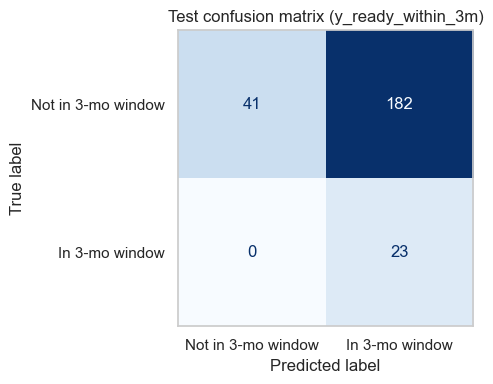

,staff_capacity_k,avg_precision_at_k,avg_recall_at_k,median_ready_cases_per_month
0,5,0.025,0.1,1.0
1,10,0.025,0.2,1.0
2,15,0.025,0.3,1.0


,month,k,topk_precision,recall_at_k,actual_ready_in_month,tp_in_top_k,rows
0,2025-08-01,5,0.000000,NaN,0,0,37
8,2025-08-01,10,0.000000,NaN,0,0,37
16,2025-08-01,15,0.000000,NaN,0,0,37
1,2025-09-01,5,0.000000,NaN,0,0,35
9,2025-09-01,10,0.000000,NaN,0,0,35
17,2025-09-01,15,0.000000,NaN,0,0,35
2,2025-10-01,5,0.000000,NaN,0,0,38
10,2025-10-01,10,0.000000,NaN,0,0,38
18,2025-10-01,15,0.000000,NaN,0,0,38
3,2025-11-01,5,0.200000,0.200000,5,1,36


Test-set Top-K rollup (mean across months; recall@K ignores months with zero positives):


,k,avg_precision_at_k,avg_recall_at_k
0,5,0.075000,0.121429
1,10,0.087500,0.307440
2,15,0.141667,0.722917


,month,rows,positives,predicted_positives,ready_rate,precision,recall,f1,pr_auc
0,2025-08-01,37,0,26,0.000000,NaN,NaN,NaN,NaN
1,2025-09-01,35,0,27,0.000000,NaN,NaN,NaN,NaN
2,2025-10-01,38,0,33,0.000000,NaN,NaN,NaN,NaN
3,2025-11-01,36,5,32,0.138889,0.156250,1.0,0.270270,0.211256
4,2025-12-01,33,7,28,0.212121,0.250000,1.0,0.400000,0.540445
5,2026-01-01,34,8,28,0.235294,0.285714,1.0,0.444444,0.257804
6,2026-02-01,28,3,26,0.107143,0.115385,1.0,0.206897,0.132593
7,2026-03-01,5,0,5,0.000000,NaN,NaN,NaN,NaN


,month,rows,positives,predicted_positives,ready_rate,precision,recall,f1,pr_auc
0,(all test months),246,23,205,0.093496,0.112195,1.0,0.201754,0.132744


Interpretation: Some months have no true positive cases in the data. In those months, precision/recall can be blank (NaN). Here, 4 of 8 test months had zero positives. For decision-making, focus most on pooled test results and the Top-K tables.


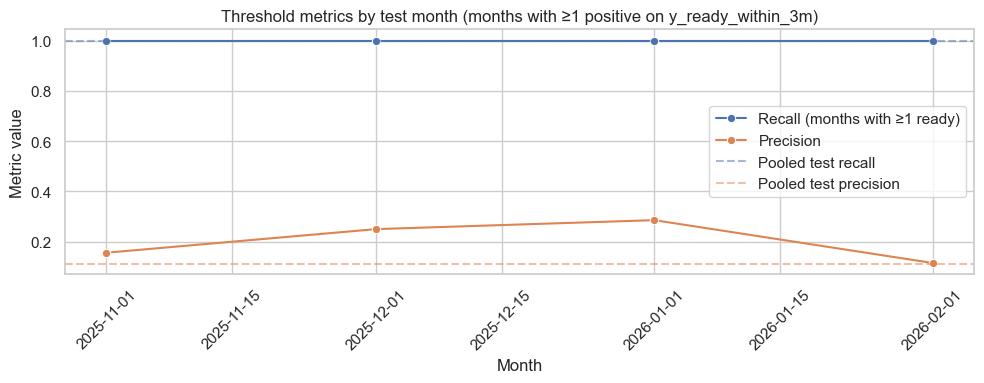

Recommended use: when staff capacity is limited, use the Top-K list first. Treat a positive model flag as a prompt for staff review—not an automatic send-out decision.


In [4]:
val_scores = best_model.predict_proba(X_val)[:, 1]
test_scores = best_model.predict_proba(X_test)[:, 1]


def metrics_at_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        'threshold': float(threshold),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'alerts': int(pred.sum()),
    }


OPERATING_POLICY = {
    # Middle-ground for operations: avoid missing girls at risk of being overlooked,
    # but keep false positives manageable for limited staff.
    'min_precision': 0.12,
    'min_recall': 0.45,
    'min_alerts': 12,
    'max_alerts': 80,
}


def choose_threshold(
    y_true,
    proba,
    min_precision=0.12,
    min_recall=0.45,
    min_alerts=12,
    max_alerts=80,
):
    p, r, t = precision_recall_curve(y_true, proba)
    if len(t) == 0:
        return 0.50, pd.DataFrame()

    candidates = [metrics_at_threshold(y_true, proba, th) for th in t]
    cand_df = pd.DataFrame(candidates)

    # Two utility views: F1 (balanced) and F2 (recall-prioritized, to reduce "fall through cracks").
    for beta, col in [(1.0, 'f1_calc'), (2.0, 'f2')]:
        b2 = beta ** 2
        cand_df[col] = np.where(
            (cand_df['precision'] + cand_df['recall']) > 0,
            (1 + b2) * cand_df['precision'] * cand_df['recall'] / (b2 * cand_df['precision'] + cand_df['recall']),
            0.0,
        )

    feasible = cand_df[
        (cand_df['precision'] >= min_precision)
        & (cand_df['recall'] >= min_recall)
        & (cand_df['alerts'] >= min_alerts)
        & (cand_df['alerts'] <= max_alerts)
    ]
    if not feasible.empty:
        # Middle-ground operating point: favor recall safety first, then precision discipline.
        picked = feasible.sort_values(['f2', 'precision', 'f1_calc'], ascending=False).iloc[0]
        return float(picked['threshold']), cand_df

    # Fallback if constraints are too strict.
    nonzero = cand_df[cand_df['alerts'] > 0]
    if not nonzero.empty:
        picked = nonzero.sort_values(['f2', 'precision', 'f1_calc'], ascending=False).iloc[0]
        return float(picked['threshold']), cand_df

    return 0.50, cand_df


selected_threshold, threshold_table = choose_threshold(y_val, val_scores, **OPERATING_POLICY)
selected_val_metrics = metrics_at_threshold(y_val, val_scores, selected_threshold)
print(f"Chosen score cutoff: {selected_threshold:.3f} (picked using validation data)")
print(
    f"Validation check -> precision: {selected_val_metrics['precision']:.3f}, "
    f"recall: {selected_val_metrics['recall']:.3f}, "
    f"F1: {selected_val_metrics['f1']:.3f}, cases flagged: {selected_val_metrics['alerts']}"
)
print(
    'Operating policy used: '
    f"min_precision={OPERATING_POLICY['min_precision']}, "
    f"min_recall={OPERATING_POLICY['min_recall']}, "
    f"min_alerts={OPERATING_POLICY['min_alerts']}, max_alerts={OPERATING_POLICY['max_alerts']}"
)

threshold_view = (
    threshold_table[['threshold', 'precision', 'recall', 'f1_calc', 'f2', 'alerts']]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['threshold'])
    .query('alerts > 0')
)
print('Validation cutoff options (best middle-ground candidates first):')
display(
    threshold_view[
        (threshold_view['precision'] >= 0.10) & (threshold_view['alerts'] >= 8)
    ].sort_values(['f2', 'precision', 'f1_calc'], ascending=False).head(15)
)

pred_test = (test_scores >= selected_threshold).astype(int)
metrics = pd.DataFrame([
    {'metric': 'PR-AUC', 'value': average_precision_score(y_test, test_scores) if y_test.nunique() > 1 else np.nan},
    {'metric': 'ROC-AUC', 'value': roc_auc_score(y_test, test_scores) if y_test.nunique() > 1 else np.nan},
    {'metric': 'Precision', 'value': precision_score(y_test, pred_test, zero_division=0)},
    {'metric': 'Recall', 'value': recall_score(y_test, pred_test, zero_division=0)},
    {'metric': 'F1', 'value': f1_score(y_test, pred_test, zero_division=0)},
])
display(metrics)
print('These results are for the main target: likely to complete reintegration within about 3 months.')

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
print('Within-3mo positives predicted negative (false negatives):', cm[1, 0])

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not in 3-mo window', 'In 3-mo window'])
grid_state = plt.rcParams.get('axes.grid', False)
plt.rcParams['axes.grid'] = False
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.grid(False, which='both')
plt.rcParams['axes.grid'] = grid_state
plt.title('Test confusion matrix (y_ready_within_3m)')
plt.tight_layout()
plt.show()

capacity_options = [5, 10, 15]
val_rank = X_val.copy()
val_rank['month'] = feature_df.loc[X_val.index, 'month'].values
val_rank['y'] = y_val.values
val_rank['score'] = val_scores

def monthly_topk_metrics(df, k):
    rows = []
    for m, g in df.groupby('month'):
        kk = min(k, len(g))
        top = g.sort_values('score', ascending=False).head(kk)
        pos = int(g['y'].sum())
        tp = int(top['y'].sum())
        rows.append({
            'month': m,
            'k': k,
            'topk_precision': float(top['y'].mean()) if kk > 0 else np.nan,
            'recall_at_k': (tp / pos) if pos > 0 else np.nan,
            'actual_ready_in_month': pos,
            'tp_in_top_k': tp,
            'rows': len(g),
        })
    return pd.DataFrame(rows)

cap_tables = []
for k in capacity_options:
    t = monthly_topk_metrics(val_rank, k)
    cap_tables.append({
        'staff_capacity_k': k,
        'avg_precision_at_k': t['topk_precision'].mean(),
        'avg_recall_at_k': np.nanmean(t['recall_at_k'].values),
        'median_ready_cases_per_month': t['actual_ready_in_month'].median(),
    })
capacity_summary = pd.DataFrame(cap_tables)
display(capacity_summary)

# Test-month Top-K (ranking lens): precision + recall among true positives that month
test_rank = X_test.copy()
test_rank['month'] = feature_df.loc[X_test.index, 'month'].values
test_rank['y'] = y_test.values
test_rank['score'] = test_scores
test_topk_rows = []
for k in capacity_options:
    test_topk_rows.append(monthly_topk_metrics(test_rank, k))
test_topk_by_month = pd.concat(test_topk_rows, ignore_index=True)
display(test_topk_by_month.sort_values(['month', 'k']))
test_topk_roll = (
    test_topk_by_month.groupby('k', as_index=False)
    .agg(avg_precision_at_k=('topk_precision', 'mean'), avg_recall_at_k=('recall_at_k', lambda s: np.nanmean(s.values)))
)
print('Test-set Top-K rollup (mean across months; recall@K ignores months with zero positives):')
display(test_topk_roll)


def monthly_threshold_metrics(y_m, s_m, threshold):
    """Precision/recall/F1 are undefined when there are zero true positives in the month."""
    p_m = (s_m >= threshold).astype(int)
    pos = int(y_m.sum())
    pred_pos = int(p_m.sum())
    if pos == 0:
        return {
            'positives': 0,
            'predicted_positives': pred_pos,
            'ready_rate': 0.0,
            'precision': np.nan,
            'recall': np.nan,
            'f1': np.nan,
            'pr_auc': np.nan,
        }
    return {
        'positives': pos,
        'predicted_positives': pred_pos,
        'ready_rate': float(y_m.mean()),
        'precision': precision_score(y_m, p_m, zero_division=0),
        'recall': recall_score(y_m, p_m, zero_division=0),
        'f1': f1_score(y_m, p_m, zero_division=0),
        'pr_auc': average_precision_score(y_m, s_m) if y_m.nunique() > 1 else np.nan,
    }


reliability_rows = []
for m, idx in feature_df.loc[feature_df['split'] == 'test'].groupby('month').groups.items():
    month_idx = list(idx)
    y_m = y.loc[month_idx]
    s_m = best_model.predict_proba(X.loc[month_idx])[:, 1]
    row = {'month': m, 'rows': len(month_idx)}
    row.update(monthly_threshold_metrics(y_m, s_m, selected_threshold))
    reliability_rows.append(row)

reliability = pd.DataFrame(reliability_rows).sort_values('month')
display(reliability)

pool_y = y_test.values
pool_s = test_scores
pool_p = (pool_s >= selected_threshold).astype(int)
pooled = {
    'month': '(all test months)',
    'rows': len(pool_y),
    'positives': int(pool_y.sum()),
    'predicted_positives': int(pool_p.sum()),
    'ready_rate': float(pool_y.mean()),
    'precision': precision_score(pool_y, pool_p, zero_division=0),
    'recall': recall_score(pool_y, pool_p, zero_division=0),
    'f1': f1_score(pool_y, pool_p, zero_division=0),
    'pr_auc': average_precision_score(pool_y, pool_s) if pool_y.sum() > 0 and (1 - pool_y).sum() > 0 else np.nan,
}
display(pd.DataFrame([pooled]))

zero_pos_months = reliability['positives'].eq(0).sum()
print(
    'Interpretation: Some months have no true positive cases in the data. In those months, precision/recall can be blank (NaN). '
    f'Here, {zero_pos_months} of {len(reliability)} test months had zero positives. '
    'For decision-making, focus most on pooled test results and the Top-K tables.'
)

rel_plot = reliability[reliability['positives'] > 0].copy()
fig, ax = plt.subplots(figsize=(10, 4))
if len(rel_plot) > 0:
    if sns is not None:
        sns.lineplot(data=rel_plot, x='month', y='recall', marker='o', label='Recall (months with ≥1 ready)', ax=ax)
        sns.lineplot(data=rel_plot, x='month', y='precision', marker='o', label='Precision', ax=ax)
    else:
        ax.plot(rel_plot['month'], rel_plot['recall'], marker='o', label='Recall (months with ≥1 ready)')
        ax.plot(rel_plot['month'], rel_plot['precision'], marker='o', label='Precision')
    ax.axhline(pooled['recall'], color='C0', linestyle='--', alpha=0.5, label='Pooled test recall')
    ax.axhline(pooled['precision'], color='C1', linestyle='--', alpha=0.5, label='Pooled test precision')
else:
    ax.text(0.5, 0.5, 'No test month has ≥1 positive label', ha='center', va='center', transform=ax.transAxes)
ax.set_title('Threshold metrics by test month (months with ≥1 positive on y_ready_within_3m)')
ax.set_ylabel('Metric value')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print('Recommended use: when staff capacity is limited, use the Top-K list first. '
      'Treat a positive model flag as a prompt for staff review—not an automatic send-out decision.')


## 5. Causal and Relationship Analysis

### What we can and cannot claim
- This section discusses **associations** in observational panel data: which resident-month patterns line up with the readiness label after we control for others in the explanatory logistic model.
- It does **not** prove that changing one factor (e.g. adding sessions) **causes** reintegration readiness; staff action, unmeasured context, and reverse paths could explain part of any pattern.

### How this ties to Section 3
Section 3 fits the same interpretable model and shows the full coefficient / odds-ratio table. **Below**, we restate the strongest signals in plain language for case conferences.

### Domain sense (hypotheses, not proof)
- **Program engagement** (sessions, attendance, progress indicators): higher engagement often aligns with readiness in social-service settings; here we only check consistency with the data.
- **Safety/stability** (incidents, severity): more or worse incidents may be associated with lower near-term readiness; again, association only.
- **Wellbeing proxies** (general health, sleep): better average wellbeing may co-occur with readiness; could also reflect support already in place.

### Practical use
- Use **predictive scores** (Sections 3–4) to decide **who to review first**.
- Use **explanatory patterns** to discuss **why** a case might need attention or what to validate in supervision.
- Final reintegration decisions remain with qualified staff and policy—not the model alone.

The next cell summarizes the top statistical signals from the explanatory table (`coef`, `odds_ratio`, `p_value` where available).


In [5]:
# Strongest associations from the explanatory model (Section 3); same data slice as when coef_tbl was fit.
rel = coef_tbl[coef_tbl['feature'] != 'const'].copy()
if rel['p_value'].notna().any():
    show = rel.nsmallest(min(8, len(rel)), 'p_value')
else:
    show = rel.assign(abs_coef=lambda d: d['coef'].abs()).sort_values('abs_coef', ascending=False).drop(columns='abs_coef').head(8)

print('Strongest association signals (explanatory logistic; controlled association in this table, not proof of cause):')
display(show[['feature', 'coef', 'odds_ratio', 'p_value']])

print('\nPlain-language readout for supervision (hypotheses for conversation, not automatic decisions):')
for _, r in show.head(5).iterrows():
    direction = 'Higher' if r['coef'] > 0 else 'Lower'
    otxt = f"{r['odds_ratio']:.2f}" if np.isfinite(r['odds_ratio']) else 'n/a'
    if pd.notna(r['p_value']):
        ptxt = f"p={r['p_value']:.3f}"
    else:
        ptxt = 'p not shown (statsmodels unavailable for exact tests)'
    print(f"- {r['feature']}: {direction} values align with higher readiness odds here (OR≈{otxt}; {ptxt}).")


Strongest association signals (explanatory logistic; controlled association in this table, not proof of cause):


,feature,coef,odds_ratio,p_value
1,months_since_admission,0.094973,1.099630,0.000731
2,sessions_3m_sum,0.147426,1.158848,0.003075
4,progress_rate_3m_mean,-3.116605,0.044307,0.011027
5,attendance_rate_3m_mean,-10.791875,0.000021,0.054759
10,incident_severity_mean_3m_mean,1.599603,4.951066,0.068921
7,general_health_score_3m_mean,-2.416172,0.089263,0.125511
6,progress_percent_3m_mean,0.024659,1.024965,0.278221
9,incident_count_3m_sum,0.274290,1.315597,0.341037



Plain-language readout for supervision (hypotheses for conversation, not automatic decisions):
- months_since_admission: Higher values align with higher readiness odds here (OR≈1.10; p=0.001).
- sessions_3m_sum: Higher values align with higher readiness odds here (OR≈1.16; p=0.003).
- progress_rate_3m_mean: Lower values align with higher readiness odds here (OR≈0.04; p=0.011).
- attendance_rate_3m_mean: Lower values align with higher readiness odds here (OR≈0.00; p=0.055).
- incident_severity_mean_3m_mean: Higher values align with higher readiness odds here (OR≈4.95; p=0.069).


## 6. Deployment Notes

### Recommended workflow each month
1. Run scores for all active residents.
2. Give staff a manageable **priority list** (Top-K).
3. Treat flags as **review prompts**, not automatic reintegration decisions.

### Playbook KPI glossary
| Metric | Plain-language meaning |
|:---|:---|
| `queue_size` | How many cases were flagged for review. |
| `review_completion_rate` | How many flagged cases were actually reviewed on time. |
| `validated_ready_rate` | How many flagged cases were confirmed ready by staff. |
| `premature_transition_rate` | How often a flagged case was judged not ready yet. |
| `time_to_reintegration_decision` | How long decisions take after a case is flagged. |

**Primary KPIs:** `validated_ready_rate`, `review_completion_rate`  
**Secondary KPIs:** `premature_transition_rate`, `time_to_reintegration_decision`, `queue_size`

### Monitoring cadence
- **Monthly:** model quality + operational KPIs.
- **Quarterly:** review threshold and retrain if needed.
- **Sooner if needed:** adjust quickly if false positives or missed cases rise.

### Synthesis (predictive vs explanatory)
- **Predictive model (Sections 3-4):** best for ranking who to review first under limited staff capacity.
- **Explanatory model (Sections 3 and 5):** best for discussing which case patterns are associated with readiness.
- **Where they work together:** scores set review order; explanatory patterns support case-conference discussion.
- **Key guardrail:** both are decision support only; final reintegration decisions stay with staff review.


In [6]:
# Resident-level deployment table: each row gets a score and a playbook tier.
# Tier C = lowest scores (below watch band). Tier B = watch band below operating cutoff. Tier A = at/above cutoff.
_tier_band_width = 0.10
tier_b_low = max(0.0, float(selected_threshold) - _tier_band_width)
if tier_b_low >= float(selected_threshold):
    tier_b_low = max(0.0, float(selected_threshold) - 1e-6)

deployment_scores = pd.DataFrame({
    'resident_id': feature_df.loc[X_test.index, 'resident_id'].values,
    'month': feature_df.loc[X_test.index, 'month'].values,
    'score': test_scores,
})
deployment_scores['tier'] = np.select(
    [
        deployment_scores['score'] >= selected_threshold,
        (deployment_scores['score'] >= tier_b_low) & (deployment_scores['score'] < selected_threshold),
    ],
    ['Tier A', 'Tier B'],
    default='Tier C',
)

deployment_scores = deployment_scores.sort_values(['month', 'score'], ascending=[True, False]).reset_index(drop=True)
deployment_scores['review_priority_in_month'] = deployment_scores.groupby('month').cumcount() + 1

display_cols = ['resident_id', 'month', 'score', 'tier', 'review_priority_in_month']
print('Deployment scoring table (test months): each resident-month has a score, tier, and review priority.')
display(deployment_scores[display_cols].head(40))

# Optional month-level summary for quick operations planning
score_summary = (
    deployment_scores.groupby(['month', 'tier'], as_index=False)
    .agg(cases=('resident_id', 'count'))
    .sort_values(['month', 'tier'])
)
print('How many cases land in each tier by month:')
display(score_summary)

playbook = pd.DataFrame([
    {
        'Tier/Rule': f'Tier A: score >= {selected_threshold:.2f}',
        'Action': 'Schedule reintegration conference within 2 weeks; validate family/home readiness documents.',
        'Owner': 'Case manager + social worker lead',
        'KPI': 'validated_ready_rate (primary), time_to_reintegration_decision (secondary)',
    },
    {
        'Tier/Rule': f'Tier B: {tier_b_low:.2f} <= score < {selected_threshold:.2f}',
        'Action': 'Assign targeted support plan and re-score next month.',
        'Owner': 'Case manager + program officer',
        'KPI': 'review_completion_rate (primary), premature_transition_rate (secondary)',
    },
    {
        'Tier/Rule': f'Tier C: score < {tier_b_low:.2f}',
        'Action': 'Continue rehabilitation plan and monitor incidents/progress monthly.',
        'Owner': 'Assigned social worker',
        'KPI': 'queue_size (secondary), support milestone completion',
    },
])
# Section 7 readability guardrail: print long-text columns as plain text to avoid truncation.
print('\nPlaybook (full text view):')
print(playbook[['Tier/Rule', 'Action', 'Owner', 'KPI']].to_string(index=False))

operating_rule = pd.DataFrame([
    {'Recommended monthly operating rule': 'If staffing capacity is ~10 reviews/month, start with Top-10 risk ranking. Recalibrate threshold quarterly when recall or validated_ready_rate drifts materially.'}
])
print(operating_rule.to_string(index=False))

print('\nMonitoring cadence and recalibration triggers:')
print('- Monthly: class balance, PR-AUC/recall, and playbook KPIs')
print('- Quarterly: threshold and model refresh review')
print('- Trigger early recalibration if PR-AUC drops >15% or recall at operating threshold falls below agreed floor')

Deployment scoring table (test months): each resident-month has a score, tier, and review priority.


,resident_id,month,score,tier,review_priority_in_month
0,60,2025-08-01,0.376287,Tier A,1
1,46,2025-08-01,0.297803,Tier A,2
2,49,2025-08-01,0.279636,Tier A,3
3,36,2025-08-01,0.276826,Tier A,4
4,8,2025-08-01,0.268295,Tier A,5
5,14,2025-08-01,0.261569,Tier A,6
6,35,2025-08-01,0.242630,Tier A,7
7,6,2025-08-01,0.222539,Tier A,8
8,50,2025-08-01,0.222125,Tier A,9
9,3,2025-08-01,0.218139,Tier A,10


How many cases land in each tier by month:


,month,tier,cases
0,2025-08-01,Tier A,26
1,2025-08-01,Tier B,11
2,2025-09-01,Tier A,27
3,2025-09-01,Tier B,8
4,2025-10-01,Tier A,33
5,2025-10-01,Tier B,5
6,2025-11-01,Tier A,32
7,2025-11-01,Tier B,4
8,2025-12-01,Tier A,28
9,2025-12-01,Tier B,5



Playbook (full text view):
                   Tier/Rule                                                                                      Action                             Owner                                                                        KPI
       Tier A: score >= 0.04 Schedule reintegration conference within 2 weeks; validate family/home readiness documents. Case manager + social worker lead validated_ready_rate (primary), time_to_reintegration_decision (secondary)
Tier B: 0.00 <= score < 0.04                                       Assign targeted support plan and re-score next month.    Case manager + program officer    review_completion_rate (primary), premature_transition_rate (secondary)
        Tier C: score < 0.00                        Continue rehabilitation plan and monitor incidents/progress monthly.            Assigned social worker                       queue_size (secondary), support milestone completion
                                                    